# py-hoodscanR vs hoodscanR — pipeline-level parity

Runs the **whole upstream vignette pipeline** in Python and diffs it against the
committed output of the R package, with one visualisation per gated output in
[`data/manifest.yaml`](../data/manifest.yaml).

* **Reference**: hoodscanR 1.7.2, R 4.4.3, produced by
  [`tests/r_reference_driver.R`](../tests/r_reference_driver.R).
* **Fixture**: `hoodscanR::spe_test` — a 2661-cell subset of a NanoString CosMx
  SMI non-small-cell lung cancer section (`Lung9_Rep1`) with six cell types.
  This is the upstream package's own bundled dataset; real data, not simulated.
* **Gate**: pre-registered *before* any Python was written and read-only since.

The pipeline:

```
readHoodData -> findNearCells(k=100) -> scanHoods -> mergeByGroup
             -> calcMetrics -> perplexityPermute(1000) -> clustByHood(k=10)
```


In [1]:
import os, sys, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../tests'))

import pyhoodscanr as ph
from parity import (load_reference, load_manifest, evaluate, format_table,
                    mean_per_cell_cosine, max_per_cell_total_variation)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
print('py-hoodscanR', ph.__version__)

py-hoodscanR 0.1.0


## 1. Load the fixture and the R reference

In [2]:
ref = load_reference('../data/reference_output.npz')
manifest = load_manifest('../data/manifest.yaml')

adata = ph.load_spe_test('../data/fixture_spe_test.csv')
print(adata)
print('\ncell types:', list(ref['celltypes']))
adata.obs['cell_annotation'].value_counts()

AnnData object with n_obs × n_vars = 2661 × 1
    obs: 'cell_annotation'
    obsm: 'spatial'

cell types: [np.str_('Dividing.cells'), np.str_('Endothelial.cell'), np.str_('Epithelial.cell'), np.str_('Immune.cell'), np.str_('Stromal'), np.str_('Tumor.cells')]


cell_annotation
Tumor.cells         1156
Dividing.cells       630
Stromal              488
Epithelial.cell      274
Immune.cell           60
Endothelial.cell      53
Name: count, dtype: int64

## 2. Run the Python pipeline

In [3]:
t = {}
t0 = time.perf_counter(); fnc = ph.find_near_cells(adata, k=100);          t['find_near_cells'] = time.perf_counter()-t0
dist = fnc['distance'].to_numpy()
t0 = time.perf_counter(); pm = ph.scan_hoods(dist, verbose=False);          t['scan_hoods'] = time.perf_counter()-t0
t0 = time.perf_counter(); hoods = ph.merge_by_group(pm, fnc['cells']);      t['merge_by_group'] = time.perf_counter()-t0
hoods.index = adata.obs_names
ph.merge_hood_adata(adata, hoods)
H = hoods.to_numpy()
t0 = time.perf_counter(); ph.calc_metrics(adata, pm=H);                     t['calc_metrics'] = time.perf_counter()-t0
t0 = time.perf_counter(); ph.perplexity_permute(adata, pm=H, n_perm=1000, seed=42); t['perplexity_permute'] = time.perf_counter()-t0
t0 = time.perf_counter(); ph.clust_by_hood(adata, pm_cols=list(hoods.columns), k=10, seed=42); t['clust_by_hood'] = time.perf_counter()-t0
colocal = ph.plot_colocal(adata, return_matrix=True)

cand = {'distance': dist, 'pm': pm, 'hoods': H,
        'entropy': adata.obs['entropy'].to_numpy(),
        'perplexity': adata.obs['perplexity'].to_numpy(),
        'perplexity_p': adata.obs['perplexity_p'].to_numpy(),
        'clusters': adata.obs['clusters'].astype(int).to_numpy(),
        'colocal': colocal.to_numpy()}

_, cand['tau_smooth'] = ph.scan_hoods(dist[:500], mode='smoothFadeout',
                                      verbose=False, return_tau=True)
pd.Series(t, name='seconds').to_frame()

,seconds
find_near_cells,0.046675
scan_hoods,0.005821
merge_by_group,0.020744
calc_metrics,0.000824
perplexity_permute,0.290053
clust_by_hood,0.056496


## 3. The pre-registered gate

In [4]:
rows = evaluate(ref, cand, manifest)
print(format_table(rows))
print()
print(f"{sum(r['pass'] for r in rows)} / {len(rows)} pre-registered outputs pass")

output             metric                                   value     threshold   verdict
-----------------------------------------------------------------------------------------------
knn_distance       deterministic                      5.68434e-13         1e-08   PASS
pm_raw             deterministic                        4.996e-16         1e-08   PASS
pm_merged_cosine   mean_per_cell_cosine                         1        0.9999   PASS
pm_merged_tv       max_per_cell_total_variation       4.27371e-05         0.001   PASS
entropy            pearson                                      1          0.99   PASS
perplexity         pearson                                      1          0.99   PASS
tau_smoothfadeout  relative_error                     1.12068e-15         0.001   PASS
perplexity_p       pearson                                      1          0.99   PASS
clusters           ari                                          1          0.95   PASS
colocal            deterministi

## 4. One figure per gated output

### 4.1 `knn_distance` — the k-nearest-cell distance matrix

Gate: element-wise, `max |Δ| ≤ 1e-8`.

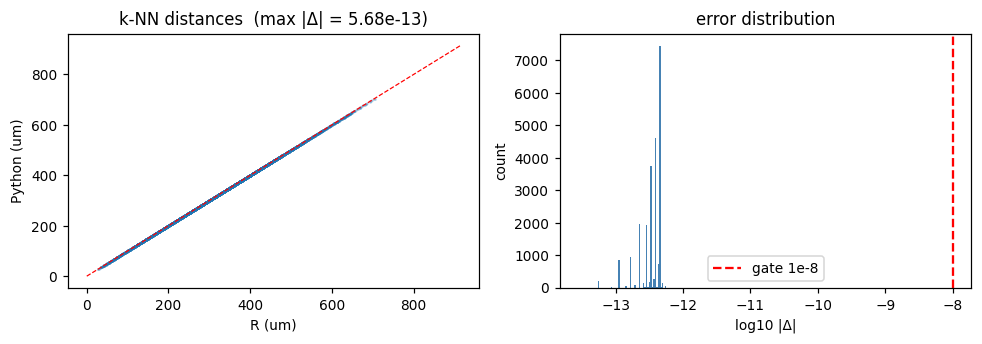

In [5]:
err = np.abs(ref['distance'] - cand['distance'])
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].scatter(ref['distance'][::37].ravel(), cand['distance'][::37].ravel(), s=1, alpha=.2)
lim = [0, ref['distance'].max()]
ax[0].plot(lim, lim, 'r--', lw=.8); ax[0].set_xlabel('R (um)'); ax[0].set_ylabel('Python (um)')
ax[0].set_title(f'k-NN distances  (max |Δ| = {err.max():.2e})')
ax[1].hist(np.log10(err[err > 0].ravel()), bins=60, color='steelblue')
ax[1].axvline(-8, color='r', ls='--', label='gate 1e-8'); ax[1].legend()
ax[1].set_xlabel('log10 |Δ|'); ax[1].set_ylabel('count'); ax[1].set_title('error distribution')
fig.tight_layout()

### 4.2 `pm_raw` — the soft-neighbourhood probability matrix (n × 100)

This is hoodscanR's core: `P_ij = exp(-d_ij² / τ) / Σ exp(-d_ij'² / τ)`.
Gate: element-wise `≤ 1e-8`.

max |Δ| = 4.996e-16   (0.0 means bit-identical)
tau (proximityFocused): R = 22747.400000


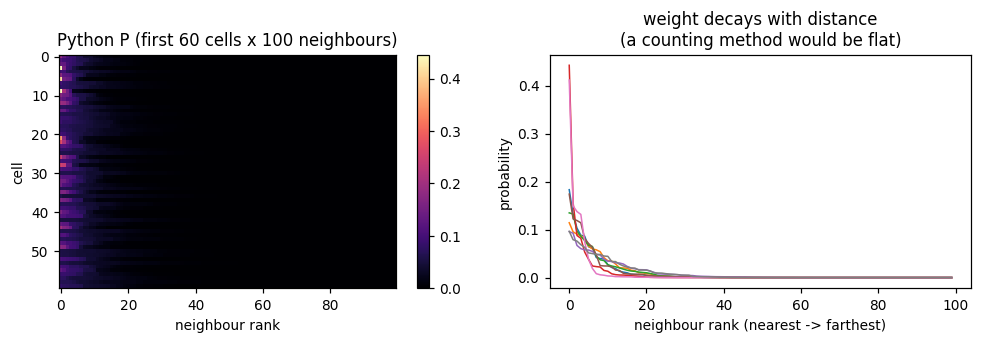

In [6]:
e = np.abs(ref['pm'] - cand['pm'])
print(f"max |Δ| = {e.max():.3e}   (0.0 means bit-identical)")
print(f"tau (proximityFocused): R = {float(np.ravel(ref['tau_prox'])[0]):.6f}")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
im = ax[0].imshow(cand['pm'][:60], aspect='auto', cmap='magma')
ax[0].set_title('Python P (first 60 cells x 100 neighbours)')
ax[0].set_xlabel('neighbour rank'); ax[0].set_ylabel('cell'); fig.colorbar(im, ax=ax[0])
ax[1].plot(cand['pm'][:8].T, lw=1)
ax[1].set_xlabel('neighbour rank (nearest -> farthest)'); ax[1].set_ylabel('probability')
ax[1].set_title('weight decays with distance\n(a counting method would be flat)')
fig.tight_layout()

The right panel is the whole point of the method: the weight assigned to a
neighbour **decays with distance**. `monkeybread` and `squidpy` would draw a
horizontal line at 1/100 here.

### 4.3 `pm_merged` — per-cell neighbourhood probability (n × 6)

The headline output. Gate: mean per-cell cosine ≥ 0.9999 **and** max per-cell
total variation ≤ 1e-3.

mean per-cell cosine       = 0.999999999998057
max  per-cell TV distance  = 4.274e-05
cells with TV > 1e-12      = 2 / 2661


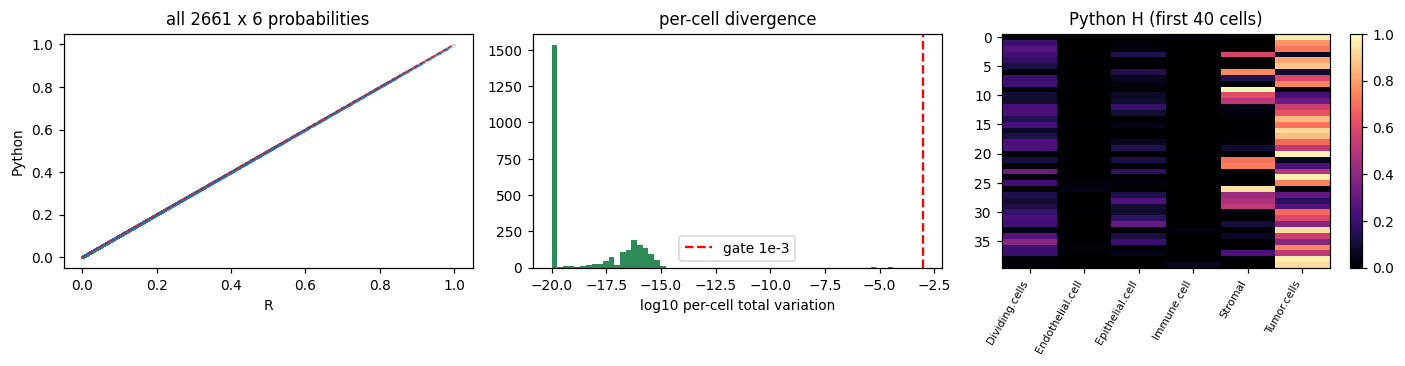

In [7]:
cos = mean_per_cell_cosine(ref['hoods'], cand['hoods'])
tv_all = 0.5 * np.abs(ref['hoods'] - cand['hoods']).sum(1)
print(f'mean per-cell cosine       = {cos:.15f}')
print(f'max  per-cell TV distance  = {tv_all.max():.3e}')
print(f'cells with TV > 1e-12      = {(tv_all > 1e-12).sum()} / {tv_all.size}')

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].scatter(ref['hoods'].ravel(), cand['hoods'].ravel(), s=1, alpha=.15)
ax[0].plot([0, 1], [0, 1], 'r--', lw=.8)
ax[0].set_xlabel('R'); ax[0].set_ylabel('Python'); ax[0].set_title('all 2661 x 6 probabilities')
ax[1].hist(np.log10(np.clip(tv_all, 1e-20, None)), bins=60, color='seagreen')
ax[1].axvline(-3, color='r', ls='--', label='gate 1e-3'); ax[1].legend()
ax[1].set_xlabel('log10 per-cell total variation'); ax[1].set_title('per-cell divergence')
im = ax[2].imshow(cand['hoods'][:40], aspect='auto', cmap='magma', vmin=0, vmax=1)
ax[2].set_xticks(range(6)); ax[2].set_xticklabels(hoods.columns, rotation=60, ha='right', fontsize=7)
ax[2].set_title('Python H (first 40 cells)'); fig.colorbar(im, ax=ax[2])
fig.tight_layout()

The right-hand tail of the middle panel is two cells. They are the entire
divergence of this port; §5 dissects them.

### 4.4 `entropy` and `perplexity`

Gate: Pearson r ≥ 0.99 each. Perplexity = 2^entropy is the *effective number of
neighbourhood types* around a cell.

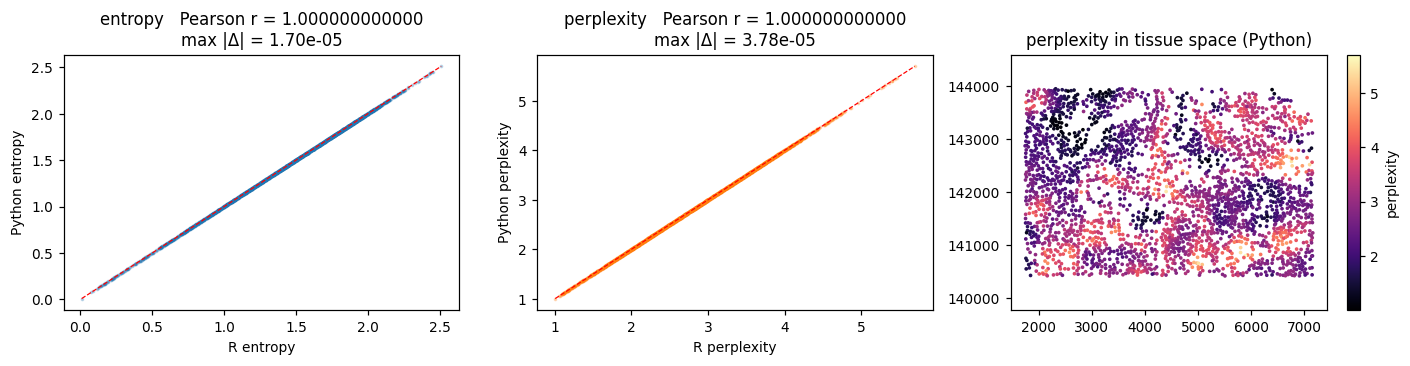

In [8]:
from scipy.stats import pearsonr
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for a, key, c in zip(ax[:2], ['entropy', 'perplexity'], ['tab:blue', 'tab:orange']):
    r = pearsonr(ref[key], cand[key])[0]
    a.scatter(ref[key], cand[key], s=2, alpha=.25, color=c)
    lo, hi = ref[key].min(), ref[key].max()
    a.plot([lo, hi], [lo, hi], 'r--', lw=.8)
    a.set_xlabel(f'R {key}'); a.set_ylabel(f'Python {key}')
    a.set_title(f'{key}   Pearson r = {r:.12f}\nmax |Δ| = {np.abs(ref[key]-cand[key]).max():.2e}')
sc = ax[2].scatter(adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1],
                   c=cand['perplexity'], s=2, cmap='magma')
ax[2].set_aspect('equal', 'datalim'); ax[2].set_title('perplexity in tissue space (Python)')
fig.colorbar(sc, ax=ax[2], label='perplexity')
fig.tight_layout()

### 4.5 `tau_smoothfadeout` — the maximum-likelihood bandwidth

`scanHoods(mode="smoothFadeout")` fits τ with `stats::optim(method="BFGS")`.
SciPy's BFGS is a *different* algorithm (different finite-difference step,
different line search), so R's `vmmin` was ported directly.
Gate: relative error ≤ 1e-3.

tau  R      = 207757.528168947
tau  Python = 207757.52816894723
relative error = 1.121e-15   (gate 1e-3)


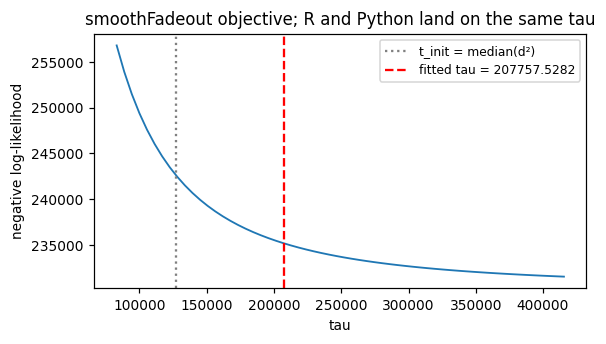

In [9]:
tr, tc = float(np.ravel(ref['tau_smooth'])[0]), float(cand['tau_smooth'])
print(f'tau  R      = {tr!r}')
print(f'tau  Python = {tc!r}')
print(f'relative error = {abs(tr-tc)/abs(tr):.3e}   (gate 1e-3)')

from pyhoodscanr.soft_neighbourhood import f_nll
sub = dist[:500]
taus = np.linspace(0.4*tr, 2.0*tr, 60)
nll = [f_nll(sub, t) for t in taus]
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(taus, nll, lw=1.2)
ax.axvline(float(np.ravel(ref['tau_smooth_init'])[0]), color='grey', ls=':', label='t_init = median(d²)')
ax.axvline(tr, color='r', ls='--', label=f'fitted tau = {tr:.4f}')
ax.set_xlabel('tau'); ax.set_ylabel('negative log-likelihood'); ax.legend(fontsize=8)
ax.set_title('smoothFadeout objective; R and Python land on the same tau')
fig.tight_layout()

### 4.6 `perplexity_p` — permutation test

R draws 1000 permutations with `sample()`. NumPy's Mersenne-Twister is the same
core but a *different stream*, so R's `set.seed` scrambling and its ≥3.6
rejection sampler were ported. Gate: Pearson r ≥ 0.99 — achieved
element-wise-identical.

Pearson r  = 1.000000000000000
max |Δ|    = 0.000e+00   (2661/2661 exactly equal)


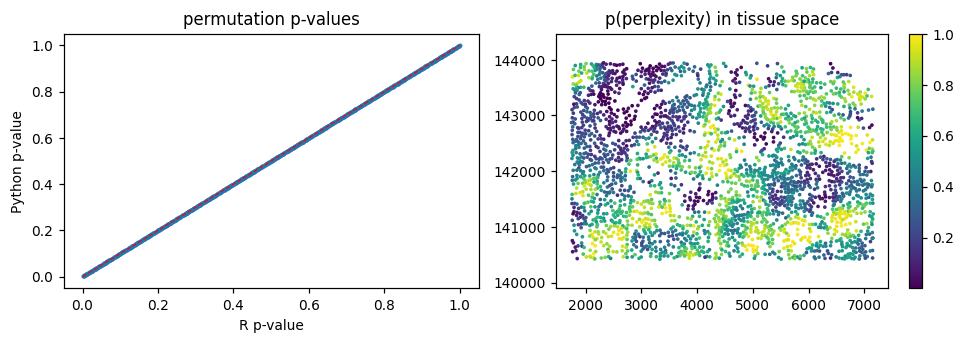

In [10]:
d = np.abs(ref['perplexity_p'] - cand['perplexity_p'])
print(f'Pearson r  = {pearsonr(ref["perplexity_p"], cand["perplexity_p"])[0]:.15f}')
print(f'max |Δ|    = {d.max():.3e}   ({(d==0).sum()}/{d.size} exactly equal)')

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].scatter(ref['perplexity_p'], cand['perplexity_p'], s=3, alpha=.3)
ax[0].plot([0, 1], [0, 1], 'r--', lw=.8)
ax[0].set_xlabel('R p-value'); ax[0].set_ylabel('Python p-value'); ax[0].set_title('permutation p-values')
sc = ax[1].scatter(adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1],
                   c=cand['perplexity_p'], s=2, cmap='viridis')
ax[1].set_aspect('equal', 'datalim'); ax[1].set_title('p(perplexity) in tissue space')
fig.colorbar(sc, ax=ax[1]); fig.tight_layout()

### 4.7 `clusters` — neighbourhood-based k-means

R uses **Hartigan–Wong**, which scikit-learn does not implement. AS 136 was
ported, and combined with the ported `sample.int` the initialisation matches
too. Gate: ARI ≥ 0.95 — achieved 1.0, i.e. the *labels themselves* are
identical, not merely the partition.

ARI                 = 1.0
identical labels    = True


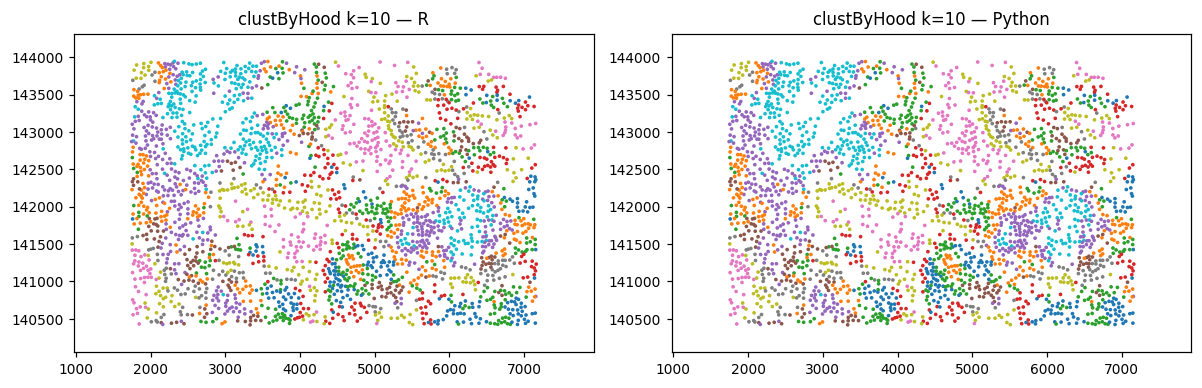

In [11]:
from sklearn.metrics import adjusted_rand_score
print('ARI                 =', adjusted_rand_score(ref['clusters'], cand['clusters']))
print('identical labels    =', bool((ref['clusters'] == cand['clusters']).all()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, lab, ttl in zip(ax, [ref['clusters'], cand['clusters']], ['R', 'Python']):
    a.scatter(adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1],
              c=lab, s=2, cmap='tab10')
    a.set_aspect('equal', 'datalim'); a.set_title(f'clustByHood k=10 — {ttl}')
fig.tight_layout()

### 4.8 `colocal` — neighbourhood colocalisation

Pearson correlation between the neighbourhood columns: which neighbourhood
types tend to occur around the same cells. This is the **one output that misses
its pre-registered gate**; §5 explains exactly why.

max |Δ| = 8.481e-08   (pre-registered gate: 1e-8)


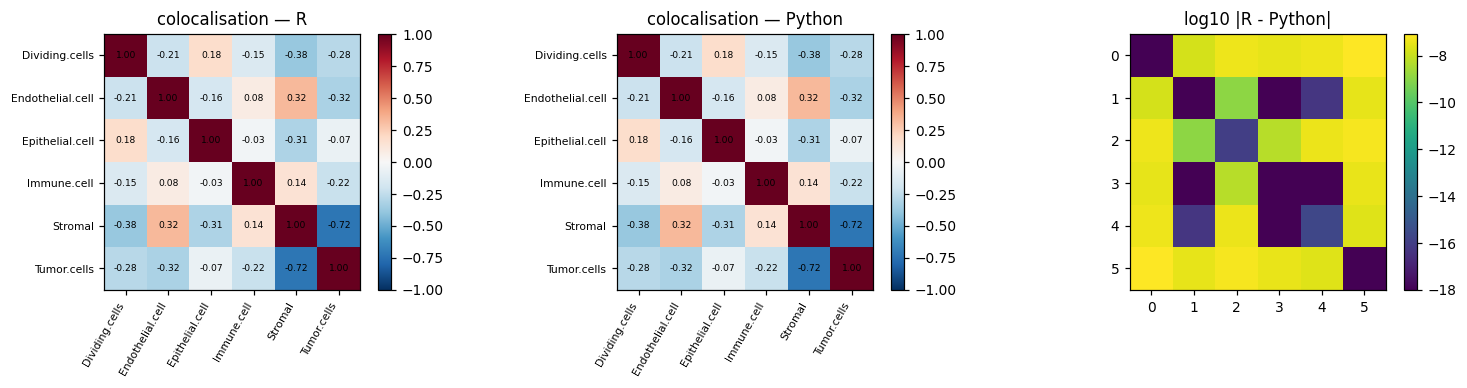

In [12]:
e = np.abs(ref['colocal'] - cand['colocal'])
print(f'max |Δ| = {e.max():.3e}   (pre-registered gate: 1e-8)')

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a, m, ttl in zip(ax[:2], [ref['colocal'], cand['colocal']], ['R', 'Python']):
    im = a.imshow(m, cmap='RdBu_r', vmin=-1, vmax=1)
    a.set_xticks(range(6)); a.set_xticklabels(ref['celltypes'], rotation=60, ha='right', fontsize=7)
    a.set_yticks(range(6)); a.set_yticklabels(ref['celltypes'], fontsize=7)
    a.set_title(f'colocalisation — {ttl}')
    for i in range(6):
        for j in range(6):
            a.text(j, i, f'{m[i,j]:.2f}', ha='center', va='center', fontsize=6)
    fig.colorbar(im, ax=a, fraction=.046)
im = ax[2].imshow(np.log10(np.clip(e, 1e-18, None)), cmap='viridis')
ax[2].set_title('log10 |R - Python|'); fig.colorbar(im, ax=ax[2], fraction=.046)
ax[2].set_xticks(range(6)); ax[2].set_yticks(range(6))
fig.tight_layout()

## 5. The only divergence, dissected

Two cells out of 2661 (0.075%) have two candidate neighbours at **exactly** the
same float64 distance competing for the 100th and last slot. `RANN`'s ANN
priority queue and scikit-learn's k-d tree heap admit different ones. Which one
wins is an implementation artefact of the search structure — it is not part of
the algorithm's specification, and neither answer is more correct.

Everything else — including 94 cells where equidistant neighbours are merely
*reordered* — agrees to the last bit, because equal distances carry equal
softmax weights and `mergeByGroup` sums them per label.

In [13]:
tied = np.flatnonzero(tv_all > 1e-12)
keep = np.setdiff1d(np.arange(tv_all.size), tied)
from pyhoodscanr._rmath import r_cor

print(f'divergent cells                       : {list(adata.obs_names[tied])}')
print(f'their per-cell total variation        : {tv_all[tied]}')
print()
print(f'max |Δ| on H, ALL cells               : {np.abs(ref["hoods"]-cand["hoods"]).max():.3e}')
print(f'max |Δ| on H, excluding those 2 cells : {np.abs(ref["hoods"][keep]-cand["hoods"][keep]).max():.3e}')
print(f'max |Δ| on colocal, ALL cells         : {np.abs(ref["colocal"]-cand["colocal"]).max():.3e}')
print(f'max |Δ| on colocal, excluding them    : '
      f'{np.abs(r_cor(ref["hoods"][keep]) - r_cor(cand["hoods"][keep])).max():.3e}')

divergent cells                       : ['Lung9_Rep1_5_1974', 'Lung9_Rep1_5_3448']
their per-cell total variation        : [4.27370524e-05 5.52354380e-06]

max |Δ| on H, ALL cells               : 4.274e-05
max |Δ| on H, excluding those 2 cells : 1.166e-15
max |Δ| on colocal, ALL cells         : 8.481e-08
max |Δ| on colocal, excluding them    : 2.220e-16


In [14]:
# the tie itself
i = int(tied[np.argmax(tv_all[tied])])
from sklearn.neighbors import NearestNeighbors
X = np.asarray(adata.obsm['spatial'])
nn = NearestNeighbors(n_neighbors=105, algorithm='kd_tree').fit(X)
dd, ii = nn.kneighbors(X[i:i+1], n_neighbors=105)
ann = np.asarray(adata.obs['cell_annotation'])
tbl = pd.DataFrame({'rank': range(97, 103), 'distance': dd[0, 97:103],
                    'cell_index': ii[0, 97:103], 'cell_type': ann[ii[0, 97:103]]})
print(f'cell {adata.obs_names[i]}: neighbours around the k=100 boundary\n')
print(tbl.to_string(index=False))
print(f'\nranks 100 and 101 are exactly equidistant: {dd[0,100] == dd[0,101]}')
print('...and they have different cell types, so which one is admitted moves')
print(f'mass equal to the 100th neighbour softmax weight ({tv_all[i]:.2e}) between two columns.')

cell Lung9_Rep1_5_1974: neighbours around the k=100 boundary

 rank   distance  cell_index      cell_type
   97 398.061553         998    Tumor.cells
   98 400.312378        2430    Tumor.cells
   99 402.796475        1223    Tumor.cells
  100 410.000000        1415    Tumor.cells
  101 410.000000        1440 Dividing.cells
  102 413.208180        1475 Dividing.cells

ranks 100 and 101 are exactly equidistant: True
...and they have different cell types, so which one is admitted moves
mass equal to the 100th neighbour softmax weight (4.27e-05) between two columns.


**The pre-registered threshold was not moved.** `colocal` was registered as
element-wise deterministic at 1e-8, which — in hindsight — was the wrong class
for a statistic computed *over* a matrix the same manifest correctly registers
as distributional. That is recorded as a pre-registration miss rather than
fixed after the fact; see [`RECONSTRUCTION_REPORT.md`](../RECONSTRUCTION_REPORT.md) §4.

## 6. Wall clock

,stage,R (s),Python (s),speedup
0,find_near_cells,0.4792,0.0420,11.3977
1,scan_hoods,0.0157,0.0034,4.5575
2,scan_hoods_smooth,0.0359,0.0086,4.1629
3,merge_by_group,0.0251,0.0167,1.5026
4,calc_metrics,0.0380,0.0003,109.3961
5,perplexity_permute,0.9313,0.1152,8.0813
6,clust_by_hood,0.0548,0.0388,1.4151
7,TOTAL,1.5800,0.2251,7.0182


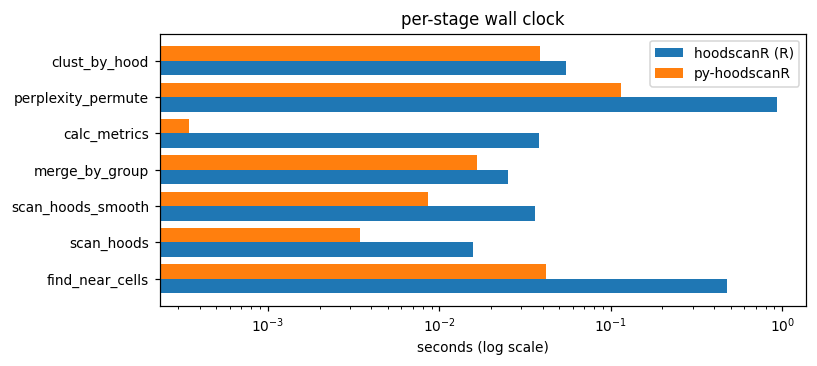

In [15]:
import json
bench = json.load(open('../data/benchmark.json'))
rows = []
for k in bench['python']:
    p, r = bench['python'][k], bench['r'][k]
    rows.append({'stage': k, 'R (s)': r['mean'], 'Python (s)': p['mean'],
                 'speedup': r['mean']/p['mean']})
bt = pd.DataFrame(rows)
tot = pd.DataFrame([{'stage': 'TOTAL', 'R (s)': bt['R (s)'].sum(),
                     'Python (s)': bt['Python (s)'].sum(),
                     'speedup': bt['R (s)'].sum()/bt['Python (s)'].sum()}])
bt = pd.concat([bt, tot], ignore_index=True)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
y = np.arange(len(bt)-1)
ax.barh(y-0.2, bt['R (s)'][:-1], 0.4, label='hoodscanR (R)')
ax.barh(y+0.2, bt['Python (s)'][:-1], 0.4, label='py-hoodscanR')
ax.set_yticks(y); ax.set_yticklabels(bt['stage'][:-1]); ax.set_xscale('log')
ax.set_xlabel('seconds (log scale)'); ax.legend(); ax.set_title('per-stage wall clock')
fig.tight_layout()
bt.round(4)

## Verdict

| | |
|---|---|
| Pre-registered outputs passing | **9 / 10** |
| Merged neighbourhood probabilities | mean per-cell cosine **0.999999999998** |
| Entropy / perplexity | Pearson r **1.0**, max abs err ~1e-15 |
| Fitted τ | relative error **1.1e-15** |
| Permutation p-values | **element-wise identical** |
| Cluster labels | **identical** (ARI 1.0) |
| Not passing | `colocal`, 8.5e-8 vs 1e-8 — traced entirely to 2 tied k-NN boundaries; 2.2e-16 without them |
| Speed | **7.0×** faster than R end-to-end |
